In [3]:
import pennylane as qml
import pandas as pd
import numpy as np
from timeit import timeit
from memory_profiler import memory_usage
import matplotlib.pyplot as plt

In [4]:
def qft(wires):
    """Manual implementation of the Quantum Fourier Transform (QFT)."""
    num_qubits = len(wires)
    for i in range(num_qubits):
        qml.Hadamard(wires=i)
        for j in range(i + 1, num_qubits):
            angle = np.pi / (2 ** (j - i))
            qml.ControlledPhaseShift(phi=angle, wires=[wires[j], wires[i]])

    # Reverse the order of the qubits to match PennyLane's native QFT
    for i in range(num_qubits // 2):
        qml.SWAP(wires=[wires[i], wires[num_qubits - i - 1]])


def qft_wrapper(num_qubits):
    """Wraps the manual QFT in a PennyLane quantum node."""
    dev = qml.device("default.qubit", wires=num_qubits)

    @qml.qnode(dev)
    def circuit():
        qft(wires=range(num_qubits))
        return qml.probs(wires=range(num_qubits))

    return circuit

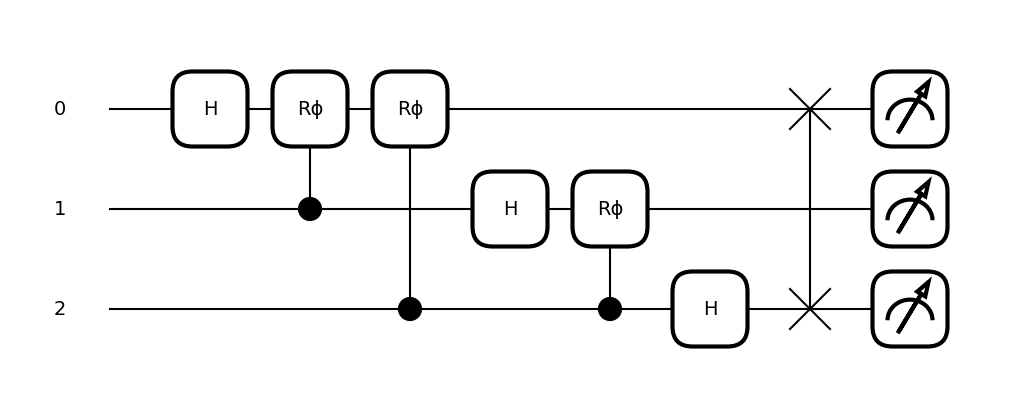

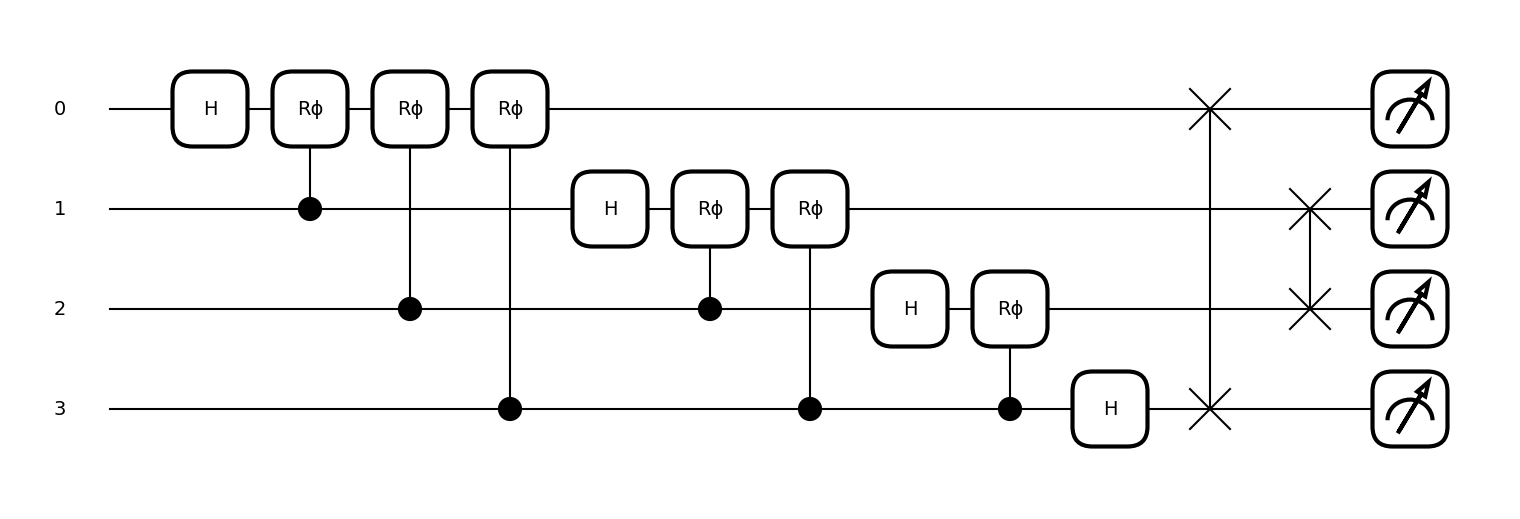

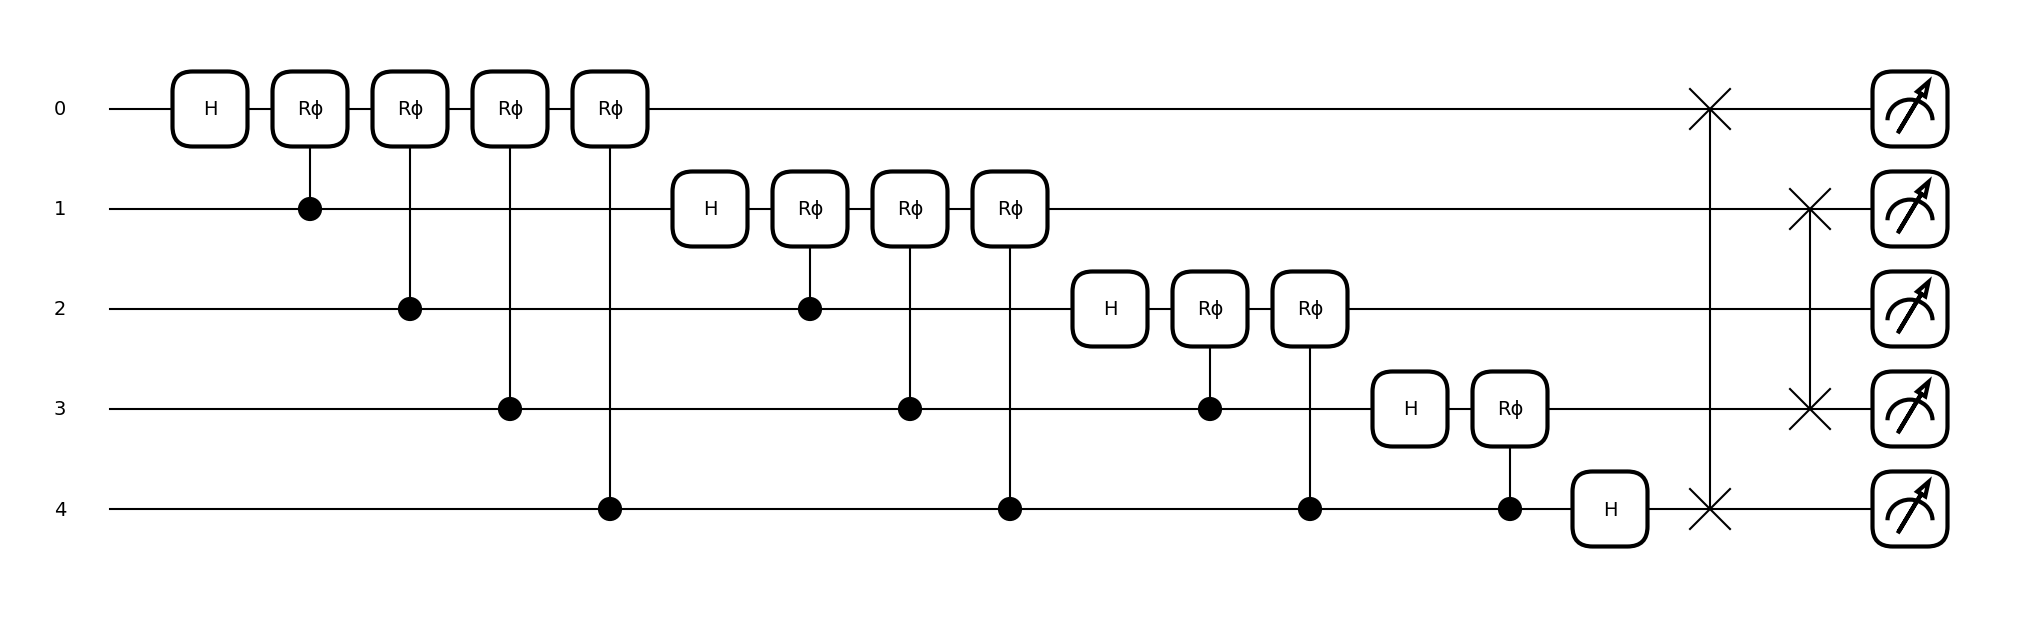

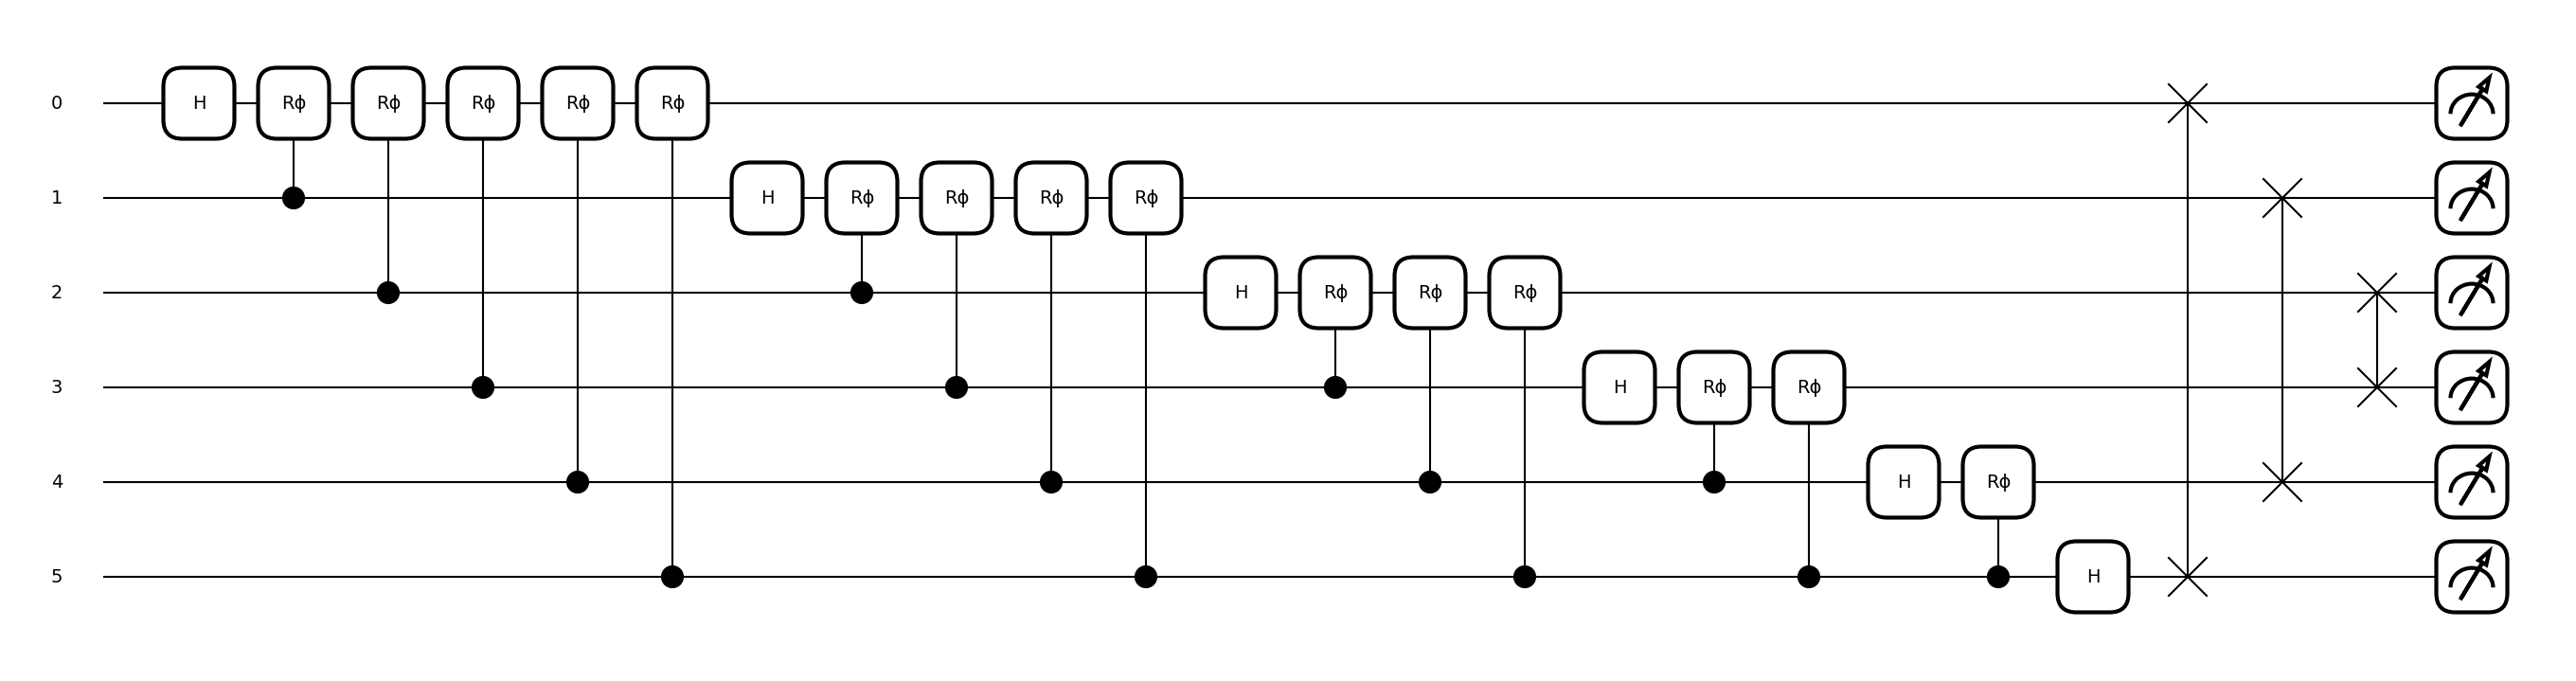

In [5]:
# Visualize the QFT circuit for different numbers of qubits
for num_qubits in range(3, 7):
    circuit = qft_wrapper(num_qubits)
    qml.draw_mpl(circuit)()

In [6]:
def pennylane_qft_wrapper(num_qubits):
    """Wraps PennyLane's native QFT in a quantum node."""
    dev = qml.device("default.qubit", wires=num_qubits)

    @qml.qnode(dev)
    def circuit():
        qml.QFT(wires=range(num_qubits))
        return qml.probs(wires=range(num_qubits))

    return circuit

In [14]:
def benchmark_qft(max_qubits=16, repetitions=5):
    """Benchmark both the manual and PennyLane QFT implementations."""
    data = []

    for num_qubits in range(3, max_qubits + 1):
        # Benchmark manual QFT
        manual_qft = qft_wrapper(num_qubits)

        # Measure average execution time
        exec_time_manual = timeit(manual_qft, number=repetitions) / repetitions

        # Measure average memory usage
        mem_usage_manual = 0
        for _ in range(repetitions):
            mem_usage = memory_usage((manual_qft), interval=0.1, include_children=True)
            mem_usage_manual += np.mean(mem_usage)
        mem_usage_manual /= repetitions

        # Benchmark PennyLane QFT
        pennylane_qft = pennylane_qft_wrapper(num_qubits)

        # Measure average execution time
        exec_time_pennylane = timeit(pennylane_qft, number=repetitions) / repetitions

        # Measure average memory usage
        mem_usage_pennylane = 0
        for _ in range(repetitions):
            mem_usage = memory_usage(
                (pennylane_qft), interval=0.1, include_children=True
            )
            mem_usage_pennylane += np.mean(mem_usage)
        mem_usage_pennylane /= repetitions

        # Store the results
        data.append(
            {
                "num_qubits": num_qubits,
                "exec_time_manual": exec_time_manual,
                "mem_usage_manual": mem_usage_manual,
                "exec_time_pennylane": exec_time_pennylane,
                "mem_usage_pennylane": mem_usage_pennylane,
            }
        )

        print(
            f"Qubits: {num_qubits:>2}, "
            f"Manual Time: {exec_time_manual:.6f} sec, Manual Memory: {mem_usage_manual:.2f} MB, "
            f"PennyLane Time: {exec_time_pennylane:.6f} sec, PennyLane Memory: {mem_usage_pennylane:.2f} MB"
        )

    # Convert the results to a pandas DataFrame for easy plotting and analysis
    df = pd.DataFrame(data)

    # Plot execution time comparison
    plt.plot(
        df["num_qubits"],
        df["exec_time_manual"],
        label="Manual QFT Time",
        color="blue",
        marker="o",
    )
    plt.plot(
        df["num_qubits"],
        df["exec_time_pennylane"],
        label="PennyLane QFT Time",
        color="green",
        marker="s",
    )
    plt.xlabel("Number of Qubits")
    plt.ylabel("Execution Time (seconds)")
    plt.title("QFT Execution Time")
    plt.legend()
    plt.xticks(df["num_qubits"])
    plt.show()

    # Plot memory usage comparison
    plt.plot(
        df["num_qubits"],
        df["mem_usage_manual"],
        label="Manual QFT Memory",
        color="blue",
        marker="o",
    )
    plt.plot(
        df["num_qubits"],
        df["mem_usage_pennylane"],
        label="PennyLane QFT Memory",
        color="green",
        marker="s",
    )
    plt.xlabel("Number of Qubits")
    plt.ylabel("Memory Usage (MB)")
    plt.title("QFT Memory Usage")
    plt.legend()
    plt.xticks(df["num_qubits"])
    plt.show()

Qubits:  3, Manual Time: 0.001145 sec, Manual Memory: 379.60 MB, PennyLane Time: 0.000525 sec, PennyLane Memory: 379.60 MB
Qubits:  4, Manual Time: 0.001708 sec, Manual Memory: 379.59 MB, PennyLane Time: 0.000526 sec, PennyLane Memory: 379.62 MB
Qubits:  5, Manual Time: 0.002522 sec, Manual Memory: 379.60 MB, PennyLane Time: 0.000501 sec, PennyLane Memory: 379.62 MB
Qubits:  6, Manual Time: 0.003196 sec, Manual Memory: 379.62 MB, PennyLane Time: 0.003043 sec, PennyLane Memory: 379.60 MB
Qubits:  7, Manual Time: 0.004348 sec, Manual Memory: 379.62 MB, PennyLane Time: 0.003916 sec, PennyLane Memory: 379.60 MB
Qubits:  8, Manual Time: 0.005379 sec, Manual Memory: 379.64 MB, PennyLane Time: 0.005223 sec, PennyLane Memory: 379.59 MB
Qubits:  9, Manual Time: 0.006835 sec, Manual Memory: 395.75 MB, PennyLane Time: 0.006554 sec, PennyLane Memory: 395.72 MB
Qubits: 10, Manual Time: 0.008676 sec, Manual Memory: 395.75 MB, PennyLane Time: 0.008346 sec, PennyLane Memory: 395.75 MB
Qubits: 11, Manu

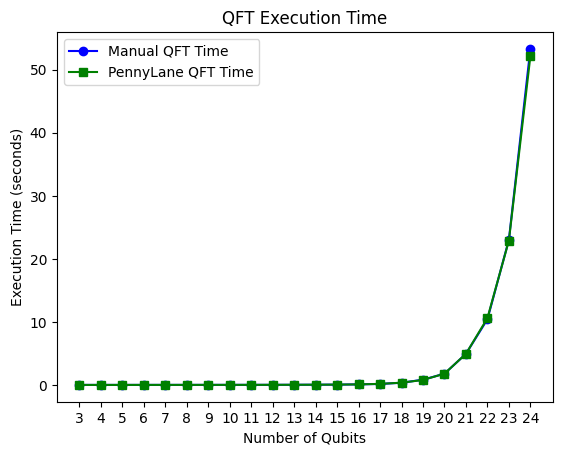

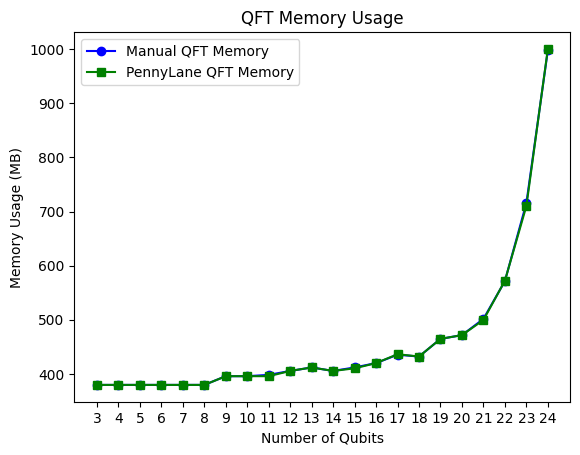

In [16]:
def main():
    num_qubits = int(input("Benchmark QFT for qubits in range [3, n]\nn = "))
    repetitions = int(
        input("Number of repetitions to average for each benchmark\nr = ")
    )
    benchmark_qft(num_qubits, repetitions)


if __name__ == "__main__":
    main()